# Concurrency

Coroutines lar mange oppgaver kjøre samtidig, og er en lettvekts måte å håndtere flere oppgaver på uten å måtte bruke tråder direkte. De er spesielt nyttige for I/O-bound oppgaver, som nettverkskommunikasjon eller filbehandling, hvor det kan være mye ventetid. Når en oppgave venter på en operasjon, kan en annen coroutine overta tråden.

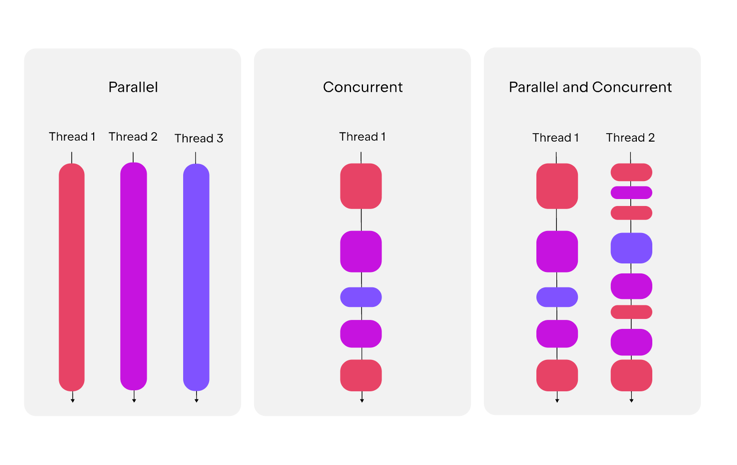

For å opprette en coroutine, kan man bruke `launch`-funksjonen
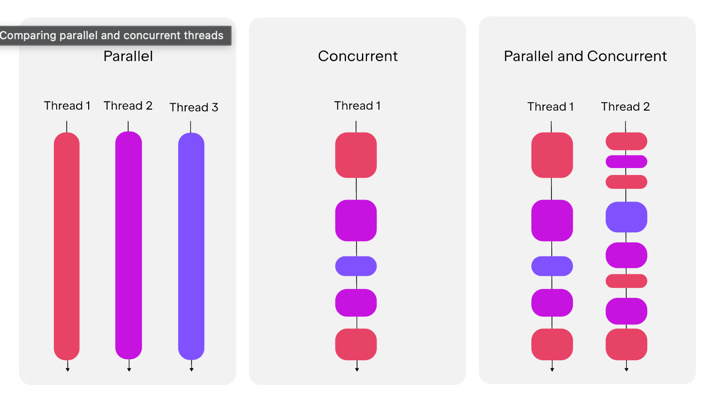

In [40]:
import kotlinx.coroutines.launch
import kotlinx.coroutines.runBlocking

runBlocking {
    launch {
        println("Hello from coroutine")
    }
}

Hello from coroutine


StandaloneCoroutine{Completed}@5a03d65

I dette eksemplet oppretter vi en coroutine som skriver ut en melding. `runBlocking` brukes for å holde hovedtråden i gang til alle coroutines er ferdige. Kotlin har et eget nøkkelord `suspend` som brukes for å markere funksjoner som kan suspendere og gjenopptas senere. Dette gjør det mulig for coroutines å vente på resultater uten å blokkere tråden.

In [43]:
import kotlinx.coroutines.delay

suspend fun suspendFunction() {
    println("This is a suspend function")
    delay(1000L) // Simulerer en langvarig operasjon
    println("Suspense done")
}

suspend fun suspendFunction2() {
    println("This is another suspend function")
}

runBlocking {
    launch { // Launch returnerer umiddelbart
        println("Hello from coroutine")
        launch {
            suspendFunction()
            println("This will print after suspending function")
        }
        println("This will print before suspendFunction is done")
        launch {
            suspendFunction2()
        }
    }
    println("This will not print last")
}

This will not print last
Hello from coroutine
This will print before suspendFunction is done
This is a suspend function
This is another suspend function
Suspense done
This will print after suspending function


## Strukturert concurrency
Coroutines kjører i et hierarki, som styrer livssyklusen. For å oppnå dette, kjører alle coroutines et `scope`.
Dette benyttes for å sikre at alle coroutines som startes innenfor samme scope, blir fullført før scope avsluttes. Når man bruker en `withContext`-blokk eller `coroutineScope`, starter coroutinene i denne blokken i samme scope. Begge er eksempler på `coroutine builders`

`Dispatchers` bestemmer hvilke(n) tråd(er) coroutines kjører på.
. `Dispatchers.IO` er optimalisert for I/O-operasjoner, mens `Dispatchers.Default` er optimalisert for CPU-intensive oppgaver. Man kan også lage egne pools med tilhørende dispatcher. IO og Default har allikevel overlappende tråder.

Dette gjør det enkelt å skrive effektiv og responsiv kode uten å bekymre seg for tråd-synkronisering eller blokkering.



In [44]:
import kotlinx.coroutines.CoroutineName
import kotlinx.coroutines.CoroutineScope
import kotlinx.coroutines.Dispatchers
import kotlinx.coroutines.coroutineScope
import kotlinx.coroutines.withContext
import kotlin.coroutines.coroutineContext

runBlocking {
    main()
}

suspend fun main() = withContext(Dispatchers.Default + CoroutineName("Default")) { // Bruker tråder i Dispatcher.Default. Kan benyttes for å endre kontekst underveis
    defaultDispatcher()
    ioDispatcher()
}

suspend fun hello()  {
    println("Hello from ${coroutineContext[CoroutineName]}")
    delay(100L)
}

suspend fun defaultDispatcher() {
    coroutineScope { // Arver Dispatcher/tråder. Dersom en jobb feiler, vil alle jobber i samme scope feile
        launch {
            hello()
        }
        launch(Dispatchers.IO + CoroutineName("Explicit IO")) {
            hello()
        }
    } // scopet vil heller ikke avsluttes før alle barn er avsluttet
    println("This will print after all children in defaultDispatcher are done")
}

suspend fun ioDispatcher() = withContext(Dispatchers.IO + CoroutineName("ioDispatcher")) {
    launch { // ekvivalent med this.launch
        hello()
    }
}

Hello from CoroutineName(Explicit IO)
Hello from CoroutineName(Default)
This will print after all children in defaultDispatcher are done
Hello from CoroutineName(ioDispatcher)


Man kan også starte asynkrone jobber som man kan vente på, tenk async/await i JavaScript. `async` returnerer en `Deferred` som man kan vente på ved å kalle `await()`. Dette er nyttig når man ønsker å kjøre flere oppgaver samtidig og vente på at alle skal fullføres før man fortsetter.

In [45]:
import kotlinx.coroutines.CoroutineScope
import kotlinx.coroutines.Dispatchers
import kotlinx.coroutines.async
import kotlinx.coroutines.awaitAll
import kotlinx.coroutines.coroutineScope
import kotlinx.coroutines.withContext

runBlocking {
    main()
}

suspend fun main() = withContext(Dispatchers.Default) { // Bruker tråder i Dispatcher.Default. Kan benyttes for å endre kontekst underveis
    val job1 = async { hello() }
    val job2 = async { world() }
    awaitAll(job1, job2)
    println("${job1.await()} ${job2.await()}")
}

suspend fun hello() : String {
    println("Hello from coroutine ${Thread.currentThread().name}")
    delay(100L)
    return "Hello"
}

suspend fun world() : String {
    println("World from coroutine ${Thread.currentThread().name}")
    return "world"
}

World from coroutine DefaultDispatcher-worker-4
Hello from coroutine DefaultDispatcher-worker-3
Hello world


For å lage en coroutine trenger man dermed:

* en suspending funksjon
* en coroutine builder (f.eks. `launch` eller `async`)
* et coroutine scope (f.eks. `runBlocking`, `coroutineScope`)
* en dispatcher (f.eks. `Dispatchers.IO` eller `Dispatchers.Default`)

https://kotlinlang.org/docs/coroutines-basics.html

The first child is failing
Cancelling the supervisor
The first child is cancelled: true, but the second one is still active
The second child is cancelled because the supervisor was cancelled
